# Ejercicio 4 — Análisis exploratorio con DuckDB

Trabajo individual. Se responde a diez preguntas analíticas sobre los viajes descargados de taxis amarillos y verdes; una consulta adicional declara cobertura y filtros.

El ejercicio considera demanda temporal, características de viajes, diferencias entre taxis, pagos, distribuciones e inconsistencias. Las consultas operan directamente sobre Parquet mediante vistas en memoria. No se importan los viajes completos a tablas ni a Pandas.

Ejecute todas las celdas. Los resultados, gráficos e interpretaciones se guardan en `docs/`; el notebook conserva también las salidas para su revisión.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts" / "analyze_trips.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts"))
from analyze_trips import create_eda_connection, run_query, plot_results, write_report, findings, SQL_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
connection = create_eda_connection()
frames = {}
print("Proyecto:", ROOT)
print("Definición de poblaciones:\n")
print((SQL_DIR / "00_poblaciones.sql").read_text())

Proyecto: /workspace
Definición de poblaciones:

-- Parte de las vistas externas definidas en sql/exploracion/00_fuentes.sql.
-- No se corrigen ni modifican los Parquet.
CREATE OR REPLACE VIEW viajes_eda AS
SELECT *, date_diff('second', recogida, llegada) / 60.0 AS duracion_minutos,
       recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH AS fecha_coherente
FROM viajes;
CREATE OR REPLACE VIEW viajes_fechas_validas AS
SELECT * FROM viajes_eda WHERE fecha_coherente;
-- Umbrales exploratorios para comparar mediciones; no reglas oficiales.
-- Pasajeros y tipo de pago NO son criterios de exclusión.
CREATE OR REPLACE VIEW viajes_mediciones_validas AS
SELECT * FROM viajes_fechas_validas
WHERE trip_distance > 0 AND trip_distance <= 100
  AND duracion_minutos > 0 AND duracion_minutos <= 1440
  AND total_amount > 0 AND fare_amount >= 0;



## Poblaciones y decisiones de calidad

- **Original:** todas las filas descargadas.
- **Fechas válidas:** recogida dentro del mes del nombre del archivo. Se usa para demanda, pagos e importes negativos.
- **Fechas y mediciones válidas:** además, distancia positiva de hasta 100 millas, duración positiva de hasta 1440 minutos, total positivo y tarifa base no negativa. Se usa para perfiles, distribuciones y relación costo/distancia.
- **Propinas de tarjeta:** agrega pago tipo 1, tarifa base positiva y propina no negativa.

Los umbrales son exploratorios, no reglas oficiales. No se cambian los archivos originales y no se descartan viajes por pasajeros o pagos nulos. Los filtros de medición se evalúan con una comparación de sensibilidad.

Los meses tienen distintos números de días, y los tipos tienen volúmenes muy diferentes. Las comparaciones temporales utilizan días calendario o porcentajes dentro de cada tipo. Los meses no publicados no se tratan como cero viajes. Las fechas de viaje se conservan sin conversión de zona horaria.

Fuente: todos los Parquet descargados de `data/raw/yellow/*/*.parquet` y `data/raw/green/*/*.parquet`, enumerados en el inventario del ejercicio 3. Las vistas externas son las de `sql/exploracion/00_fuentes.sql`.

## 01_cobertura: Cobertura y poblaciones

**Pregunta:** ¿Qué proporción de datos conserva cada población de análisis?

**Justificación:** Las alertas del ejercicio 3 requieren declarar denominadores y filtros antes de interpretar resultados.

**Población:** Todos los viajes originales.

**SQL:** `sql/eda/01_cobertura.sql`.

In [2]:
name = '01_cobertura'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Expone denominadores y causas de exclusión (pueden solaparse).
SELECT tipo_taxi, count(*) AS registros_originales,
       count_if(fecha_coherente) AS fechas_validas,
       count_if(fecha_coherente AND trip_distance > 0 AND trip_distance <= 100
         AND duracion_minutos > 0 AND duracion_minutos <= 1440
         AND total_amount > 0 AND fare_amount >= 0) AS mediciones_validas,
       count_if(NOT fecha_coherente OR fecha_coherente IS NULL) AS fecha_excluida,
       count_if(trip_distance IS NULL OR trip_distance <= 0 OR trip_distance > 100) AS distancia_alerta,
       count_if(duracion_minutos IS NULL OR duracion_minutos <= 0 OR duracion_minutos > 1440) AS duracion_alerta,
       count_if(total_amount IS NULL OR total_amount <= 0 OR fare_amount IS NULL OR fare_amount < 0) AS importe_alerta
FROM viajes_eda GROUP BY tipo_taxi ORDER BY tipo_taxi;



,tipo_taxi,registros_originales,fechas_validas,mediciones_validas,fecha_excluida,distancia_alerta,duracion_alerta,importe_alerta
0,green,337114,337016.0,323668.0,98.0,12284.0,238.0,1568.0
1,yellow,29703355,29703209.0,28240105.0,146.0,953454.0,371946.0,167228.0


**Interpretación y límites:** Las causas de exclusión pueden solaparse y no se suman para obtener filas únicas.

Resultado completo: `docs/resultados_ejercicio_4/01_cobertura.csv`.

## 02_demanda_mensual: Demanda mensual

**Pregunta:** ¿Cómo cambia el volumen mensual y el promedio diario de viajes?

**Justificación:** Los meses tienen distinta duración; comparar solo totales puede confundir calendario con demanda.

**Población:** Viajes con fechas coherentes con el archivo.

**SQL:** `sql/eda/02_demanda_mensual.sql`.

In [3]:
name = '02_demanda_mensual'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Promedio diario: usa días del mes, incluidos posibles días sin viajes.
SELECT tipo_taxi, mes_archivo, count(*) AS viajes,
       day(last_day(mes_archivo)) AS dias_calendario,
       count(DISTINCT CAST(recogida AS DATE)) AS dias_con_viajes,
       round(count(*)::DOUBLE / day(last_day(mes_archivo)), 2) AS viajes_por_dia
FROM viajes_fechas_validas
GROUP BY tipo_taxi, mes_archivo ORDER BY tipo_taxi, mes_archivo;



,tipo_taxi,mes_archivo,viajes,dias_calendario,dias_con_viajes,viajes_por_dia
0,green,2026-01-01,40250,31,31,1298.39
1,green,2026-02-01,37362,28,28,1334.36
2,green,2026-03-01,44199,31,31,1425.77
3,green,2026-04-01,44235,30,30,1474.50
4,green,2026-05-01,44911,31,31,1448.74
5,green,2026-06-01,44150,30,30,1471.67
6,green,2026-07-01,41236,31,31,1330.19
7,green,2026-08-01,40673,31,31,1312.03
8,yellow,2026-01-01,3724882,31,31,120157.48
9,yellow,2026-02-01,3399850,28,28,121423.21


**Interpretación y límites:** La comparación principal usa viajes por día calendario; se informa también cuántos días presentan viajes.

Resultado completo: `docs/resultados_ejercicio_4/02_demanda_mensual.csv`.

## 03_demanda_horaria: Demanda por hora

**Pregunta:** ¿A qué horas se concentran los viajes y difieren los perfiles entre taxis?

**Justificación:** Las marcas de recogida permiten detectar patrones de uso; los volúmenes de ambos tipos son muy distintos.

**Población:** Viajes con fechas coherentes con el archivo.

**SQL:** `sql/eda/03_demanda_horaria.sql`.

In [4]:
name = '03_demanda_horaria'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Porcentajes dentro de cada tipo; evita que el volumen amarillo oculte al verde.
SELECT tipo_taxi, hour(recogida) AS hora, count(*) AS viajes,
       100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi) AS porcentaje_tipo
FROM viajes_fechas_validas
GROUP BY tipo_taxi, hora ORDER BY tipo_taxi, hora;



,tipo_taxi,hora,viajes,porcentaje_tipo
0,green,0,5287,1.568768
1,green,1,3370,0.999953
2,green,2,2459,0.729639
3,green,3,2041,0.605609
4,green,4,2057,0.610357
5,green,5,2655,0.787796
6,green,6,6811,2.020972
7,green,7,14213,4.217307
8,green,8,17911,5.314584
9,green,9,18819,5.584008


**Interpretación y límites:** Se comparan porcentajes dentro de cada tipo, no conteos sobre una escala dominada por amarillos.

Resultado completo: `docs/resultados_ejercicio_4/03_demanda_horaria.csv`.

## 04_demanda_semanal: Demanda por día de semana

**Pregunta:** ¿Qué días de la semana presentan mayor demanda diaria promedio?

**Justificación:** Los días de semana no aparecen la misma cantidad de veces en el calendario disponible.

**Población:** Viajes con fechas coherentes con el archivo.

**SQL:** `sql/eda/04_demanda_semanal.sql`.

In [5]:
name = '04_demanda_semanal'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Divide por el número de veces que cada día aparece en los meses disponibles.
-- ISO: 1=lunes, ..., 7=domingo; evita comparar conteos con calendarios desiguales.
WITH meses AS (
    SELECT DISTINCT tipo_taxi, mes_archivo FROM viajes_eda
), calendario AS (
    SELECT tipo_taxi, CAST(dia AS DATE) AS fecha
    FROM meses, LATERAL generate_series(mes_archivo, last_day(mes_archivo), INTERVAL 1 DAY) AS fechas(dia)
), dias AS (
    SELECT tipo_taxi, isodow(fecha) AS dia_semana, count(*) AS dias_calendario
    FROM calendario GROUP BY tipo_taxi, dia_semana
), conteos AS (
    SELECT tipo_taxi, isodow(recogida) AS dia_semana, count(*) AS viajes
    FROM viajes_fechas_validas GROUP BY tipo_taxi, dia_semana
)
SELECT d.tipo_taxi, d.dia_semana, d.dias_calendario, coalesce(c.viajes, 0) AS viajes,
       coalesce(c.viajes, 0)::DOUBLE / d.dias_calendario AS viajes_por_dia
FROM dias d LEFT JOIN conteos c USING (tipo_taxi, dia_semana)
ORDER BY d.tipo_taxi, d.dia_semana;



,tipo_taxi,dia_semana,dias_calendario,viajes,viajes_por_dia
0,green,1,35,47912,1368.914286
1,green,2,34,50794,1493.941176
2,green,3,34,52679,1549.382353
3,green,4,35,55659,1590.257143
4,green,5,35,50671,1447.742857
5,green,6,35,40764,1164.685714
6,green,7,35,38537,1101.057143
7,yellow,1,35,3552482,101499.485714
8,yellow,2,34,4066804,119611.882353
9,yellow,3,34,4339210,127623.823529


**Interpretación y límites:** Cada conteo se divide por las ocurrencias de ese día en los meses descargados; los posibles días sin viajes cuentan como cero.

Resultado completo: `docs/resultados_ejercicio_4/04_demanda_semanal.csv`.

## 05_perfil_viajes: Características de los viajes

**Pregunta:** ¿Cómo difieren distancia, duración y total pagado entre amarillos y verdes?

**Justificación:** Los extremos observados en el ejercicio 3 aconsejan contrastar medias con medianas y percentiles.

**Población:** Viajes con fechas y mediciones válidas.

**SQL:** `sql/eda/05_perfil_viajes.sql`.

In [6]:
name = '05_perfil_viajes'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Perfil del subconjunto con mediciones válidas. Percentiles aproximados.
SELECT tipo_taxi, count(*) AS viajes,
       avg(trip_distance) AS distancia_media_millas,
       approx_quantile(trip_distance, 0.5) AS distancia_mediana_millas,
       approx_quantile(trip_distance, 0.95) AS distancia_p95_millas,
       avg(duracion_minutos) AS duracion_media_minutos,
       approx_quantile(duracion_minutos, 0.5) AS duracion_mediana_minutos,
       approx_quantile(duracion_minutos, 0.95) AS duracion_p95_minutos,
       avg(total_amount) AS total_medio_usd,
       approx_quantile(total_amount, 0.5) AS total_mediano_usd,
       approx_quantile(total_amount, 0.95) AS total_p95_usd
FROM viajes_mediciones_validas GROUP BY tipo_taxi ORDER BY tipo_taxi;



,tipo_taxi,viajes,distancia_media_millas,distancia_mediana_millas,distancia_p95_millas,duracion_media_minutos,duracion_mediana_minutos,duracion_p95_minutos,total_medio_usd,total_mediano_usd,total_p95_usd
0,green,323668,3.360555,2.144442,10.678232,21.242846,13.348156,45.213704,25.573621,20.572578,57.009257
1,yellow,28240105,3.517593,1.933930,12.694793,17.948974,14.123804,44.206422,30.244625,23.578539,77.460670


**Interpretación y límites:** Los percentiles son aproximados; las diferencias describen este subconjunto y no prueban una causa.

Resultado completo: `docs/resultados_ejercicio_4/05_perfil_viajes.csv`.

## 06_distribuciones: Distribuciones

**Pregunta:** ¿Predominan los viajes cortos y cómo se distribuyen duraciones y pagos?

**Justificación:** Una media no muestra la concentración ni la cola de la distribución.

**Población:** Viajes con fechas y mediciones válidas.

**SQL:** `sql/eda/06_distribuciones.sql`.

In [7]:
name = '06_distribuciones'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Distribuciones por intervalos explícitos; porcentajes por tipo y variable.
WITH intervalos AS (
    SELECT tipo_taxi, 'distancia_millas' AS variable,
       CASE WHEN trip_distance <= 1 THEN 1 WHEN trip_distance <= 2 THEN 2
            WHEN trip_distance <= 5 THEN 3 WHEN trip_distance <= 10 THEN 4
            WHEN trip_distance <= 20 THEN 5 ELSE 6 END AS orden,
       CASE WHEN trip_distance <= 1 THEN '(0, 1]' WHEN trip_distance <= 2 THEN '(1, 2]'
            WHEN trip_distance <= 5 THEN '(2, 5]' WHEN trip_distance <= 10 THEN '(5, 10]'
            WHEN trip_distance <= 20 THEN '(10, 20]' ELSE '(20, 100]' END AS intervalo
    FROM viajes_mediciones_validas
    UNION ALL
    SELECT tipo_taxi, 'duracion_minutos',
       CASE WHEN duracion_minutos <= 5 THEN 1 WHEN duracion_minutos <= 10 THEN 2
            WHEN duracion_minutos <= 20 THEN 3 WHEN duracion_minutos <= 40 THEN 4
            WHEN duracion_minutos <= 60 THEN 5 ELSE 6 END,
       CASE WHEN duracion_minutos <= 5 THEN '(0, 5]' WH

,tipo_taxi,variable,orden,intervalo,viajes,porcentaje
0,green,distancia_millas,1,"(0, 1]",46328,14.313432
1,green,distancia_millas,2,"(1, 2]",104953,32.426128
2,green,distancia_millas,3,"(2, 5]",113576,35.090278
3,green,distancia_millas,4,"(5, 10]",40157,12.406849
4,green,distancia_millas,5,"(10, 20]",16891,5.218619
5,green,distancia_millas,6,"(20, 100]",1763,0.544694
6,yellow,distancia_millas,1,"(0, 1]",6201646,21.960421
7,yellow,distancia_millas,2,"(1, 2]",8420162,29.816327
8,yellow,distancia_millas,3,"(2, 5]",8093288,28.658845
9,yellow,distancia_millas,4,"(5, 10]",3369353,11.931092


**Interpretación y límites:** Los intervalos se fijan explícitamente y sus porcentajes usan el total de cada tipo y variable.

Resultado completo: `docs/resultados_ejercicio_4/06_distribuciones.csv`.

## 07_costo_distancia: Costo según distancia

**Pregunta:** ¿Cómo cambia el total mediano según el intervalo de distancia?

**Justificación:** Distancia y total pueden estar asociados, pero el total incluye conceptos adicionales a la tarifa base.

**Población:** Viajes con fechas y mediciones válidas.

**SQL:** `sql/eda/07_costo_distancia.sql`.

In [8]:
name = '07_costo_distancia'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Asociación descriptiva; no estima un efecto causal ni una tarifa por milla.
WITH grupos AS (
    SELECT *, CASE WHEN trip_distance <= 1 THEN 1 WHEN trip_distance <= 2 THEN 2
                  WHEN trip_distance <= 5 THEN 3 WHEN trip_distance <= 10 THEN 4
                  WHEN trip_distance <= 20 THEN 5 ELSE 6 END AS orden,
       CASE WHEN trip_distance <= 1 THEN '(0, 1]' WHEN trip_distance <= 2 THEN '(1, 2]'
            WHEN trip_distance <= 5 THEN '(2, 5]' WHEN trip_distance <= 10 THEN '(5, 10]'
            WHEN trip_distance <= 20 THEN '(10, 20]' ELSE '(20, 100]' END AS intervalo_millas
    FROM viajes_mediciones_validas
)
SELECT tipo_taxi, orden, intervalo_millas, count(*) AS viajes,
       approx_quantile(total_amount, 0.5) AS total_mediano_usd,
       approx_quantile(duracion_minutos, 0.5) AS duracion_mediana_minutos
FROM grupos GROUP BY tipo_taxi, orden, intervalo_millas
ORDER BY tipo_taxi, orden;



,tipo_taxi,orden,intervalo_millas,viajes,total_mediano_usd,duracion_mediana_minutos
0,green,1,"(0, 1]",46328,11.327909,5.270875
1,green,2,"(1, 2]",104953,16.000476,9.851325
2,green,3,"(2, 5]",113576,24.682752,16.483001
3,green,4,"(5, 10]",40157,40.394618,27.009996
4,green,5,"(10, 20]",16891,55.660359,43.510142
5,green,6,"(20, 100]",1763,95.033251,64.157202
6,yellow,1,"(0, 1]",6201646,14.851496,6.019687
7,yellow,2,"(1, 2]",8420162,19.835626,10.957443
8,yellow,3,"(2, 5]",8093288,28.226525,18.031991
9,yellow,4,"(5, 10]",3369353,43.098700,25.792568


**Interpretación y límites:** No se interpreta como efecto causal ni como tarifa por milla; los intervalos largos pueden tener pocos viajes.

Resultado completo: `docs/resultados_ejercicio_4/07_costo_distancia.csv`.

## 08_formas_pago: Formas de pago

**Pregunta:** ¿Qué modalidades de pago predominan y qué diferencias aparecen entre tipos?

**Justificación:** La exploración encontró Flex Fare y pagos nulos; eliminarlos alteraría la composición observada.

**Población:** Viajes con fechas coherentes con el archivo.

**SQL:** `sql/eda/08_formas_pago.sql`.

In [9]:
name = '08_formas_pago'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Conserva NULL y Flex Fare; usa la población con fechas válidas.
SELECT tipo_taxi, payment_type,
       CASE payment_type WHEN 0 THEN 'Flex Fare' WHEN 1 THEN 'Tarjeta'
            WHEN 2 THEN 'Efectivo' WHEN 3 THEN 'Sin cargo' WHEN 4 THEN 'Disputa'
            WHEN 5 THEN 'Desconocido' WHEN 6 THEN 'Anulado'
            ELSE CASE WHEN payment_type IS NULL THEN 'Sin dato' ELSE 'No documentado' END END AS forma_pago,
       count(*) AS viajes,
       100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi) AS porcentaje_tipo
FROM viajes_fechas_validas
GROUP BY tipo_taxi, payment_type ORDER BY tipo_taxi, payment_type;



,tipo_taxi,payment_type,forma_pago,viajes,porcentaje_tipo
0,green,1,Tarjeta,219903,65.250018
1,green,2,Efectivo,65902,19.554561
2,green,3,Sin cargo,1686,0.500273
3,green,4,Disputa,750,0.222541
4,green,<NA>,Sin dato,48775,14.472607
5,yellow,0,Flex Fare,7716688,25.979307
6,yellow,1,Tarjeta,18940892,63.767157
7,yellow,2,Efectivo,2708007,9.116884
8,yellow,3,Sin cargo,98132,0.330375
9,yellow,4,Disputa,239488,0.806270


**Interpretación y límites:** Se conservan Flex Fare y Sin dato. Una categoría ausente no equivale a efectivo ni a tarjeta.

Resultado completo: `docs/resultados_ejercicio_4/08_formas_pago.csv`.

## 09_propinas_tarjeta: Propinas registradas en tarjeta

**Pregunta:** ¿Cómo difieren las propinas registradas en los viajes pagados con tarjeta?

**Justificación:** Los diccionarios TLC indican que las propinas en efectivo no se registran.

**Población:** Mediciones válidas, payment_type=1, fare_amount>0 y tip_amount>=0.

**SQL:** `sql/eda/09_propinas_tarjeta.sql`.

In [10]:
name = '09_propinas_tarjeta'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- TLC: las propinas en efectivo no están incluidas. No se comparan con tarjeta.
-- Denominador de la tasa: tarifa base fare_amount, no total_amount.
SELECT tipo_taxi, count(*) AS viajes_tarjeta_elegibles,
       count_if(tip_amount = 0) AS viajes_sin_propina_registrada,
       100.0 * count_if(tip_amount = 0) / count(*) AS porcentaje_sin_propina,
       avg(tip_amount) AS propina_media_usd,
       approx_quantile(tip_amount, 0.5) AS propina_mediana_usd,
       avg(100.0 * tip_amount / fare_amount) AS tasa_media_porcentaje,
       approx_quantile(100.0 * tip_amount / fare_amount, 0.5) AS tasa_mediana_porcentaje
FROM viajes_mediciones_validas
WHERE payment_type = 1 AND fare_amount > 0 AND tip_amount >= 0
GROUP BY tipo_taxi ORDER BY tipo_taxi;



,tipo_taxi,viajes_tarjeta_elegibles,viajes_sin_propina_registrada,porcentaje_sin_propina,propina_media_usd,propina_mediana_usd,tasa_media_porcentaje,tasa_mediana_porcentaje
0,green,212456,18408.0,8.664382,3.809153,3.109436,22.965179,23.566673
1,yellow,18460906,1639752.0,8.882294,4.256022,3.278658,25.094140,26.411139


**Interpretación y límites:** La tasa es propina/tarifa base por viaje. No representa todas las propinas ni se compara con efectivo.

Resultado completo: `docs/resultados_ejercicio_4/09_propinas_tarjeta.csv`.

## 10_importes_negativos: Importes negativos y pagos

**Pregunta:** ¿En qué formas de pago aparecen totales negativos y qué proporción representan?

**Justificación:** El signo negativo requiere contexto; los códigos de pago incluyen disputas y viajes sin cargo.

**Población:** Viajes con fechas coherentes con el archivo, incluidos los importes negativos.

**SQL:** `sql/eda/10_importes_negativos.sql`.

In [11]:
name = '10_importes_negativos'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Proporción negativa dentro de cada categoría, no solamente conteos.
SELECT tipo_taxi, payment_type, count(*) AS viajes_categoria,
       count_if(total_amount < 0) AS totales_negativos,
       100.0 * count_if(total_amount < 0) / count(*) AS porcentaje_negativo_categoria
FROM viajes_fechas_validas
GROUP BY tipo_taxi, payment_type ORDER BY tipo_taxi, payment_type;



,tipo_taxi,payment_type,viajes_categoria,totales_negativos,porcentaje_negativo_categoria
0,green,1,219903,137.0,0.062300
1,green,2,65902,43.0,0.065248
2,green,3,1686,563.0,33.392645
3,green,4,750,279.0,37.200000
4,green,<NA>,48775,0.0,0.000000
5,yellow,0,7716688,94.0,0.001218
6,yellow,1,18940892,3511.0,0.018537
7,yellow,2,2708007,39646.0,1.464029
8,yellow,3,98132,17727.0,18.064444
9,yellow,4,239488,100854.0,42.112340


**Interpretación y límites:** Se informa la proporción negativa dentro de cada categoría sin atribuir automáticamente su causa.

Resultado completo: `docs/resultados_ejercicio_4/10_importes_negativos.csv`.

## 11_sensibilidad: Sensibilidad a los filtros

**Pregunta:** ¿Cuánto cambian las medias al aplicar los filtros de medición?

**Justificación:** El subconjunto filtrado cambia la cobertura y puede modificar las conclusiones.

**Población:** Comparación entre fechas válidas y fechas+mediciones válidas.

**SQL:** `sql/eda/11_sensibilidad.sql`.

In [12]:
name = '11_sensibilidad'
print((SQL_DIR / (name + ".sql")).read_text())
frames[name] = run_query(connection, name)
display(frames[name])

-- Muestra el efecto del filtrado en tamaños y medias; no atribuye todo a un único filtro.
SELECT 'Fechas válidas, sin filtros de medición' AS poblacion, tipo_taxi,
       count(*) AS viajes, avg(trip_distance) AS distancia_media_millas,
       avg(duracion_minutos) AS duracion_media_minutos, avg(total_amount) AS total_medio_usd
FROM viajes_fechas_validas GROUP BY tipo_taxi
UNION ALL
SELECT 'Fechas y mediciones válidas', tipo_taxi, count(*), avg(trip_distance),
       avg(duracion_minutos), avg(total_amount)
FROM viajes_mediciones_validas GROUP BY tipo_taxi
ORDER BY tipo_taxi, poblacion;



,poblacion,tipo_taxi,viajes,distancia_media_millas,duracion_media_minutos,total_medio_usd
0,"Fechas válidas, sin filtros de medición",green,337016,13.352213,20.769289,25.490076
1,Fechas y mediciones válidas,green,323668,3.360555,21.242846,25.573621
2,"Fechas válidas, sin filtros de medición",yellow,29703209,5.552950,17.644265,30.069703
3,Fechas y mediciones válidas,yellow,28240105,3.517593,17.948974,30.244625


**Interpretación y límites:** Cambian varios criterios simultáneamente; no se atribuye toda la diferencia a un único filtro.

Resultado completo: `docs/resultados_ejercicio_4/11_sensibilidad.csv`.

## Visualizaciones y documentación

Los gráficos usan únicamente resultados agregados obtenidos de DuckDB. Las figuras de demanda mensual y semanal separan los tipos y tienen escalas verticales independientes; las comparaciones de proporciones usan una escala común.

### 02_demanda_mensual

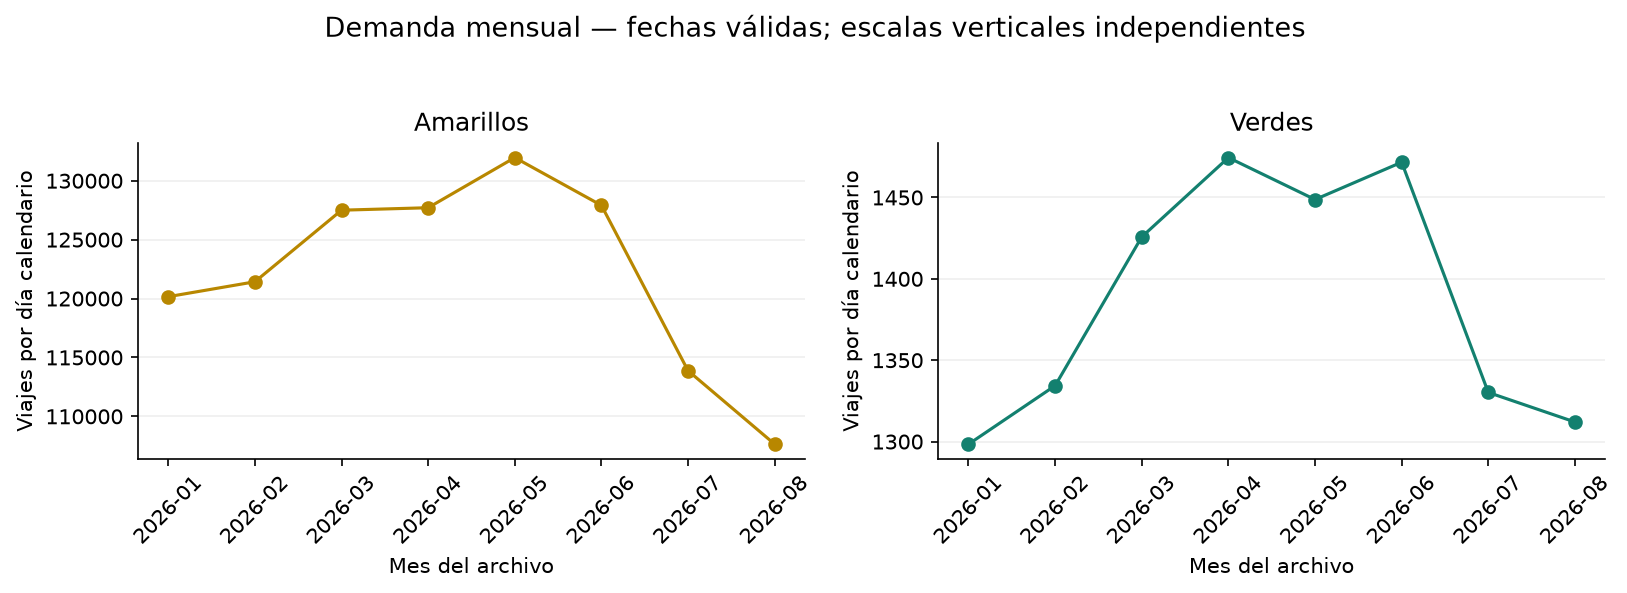

### 03_demanda_horaria

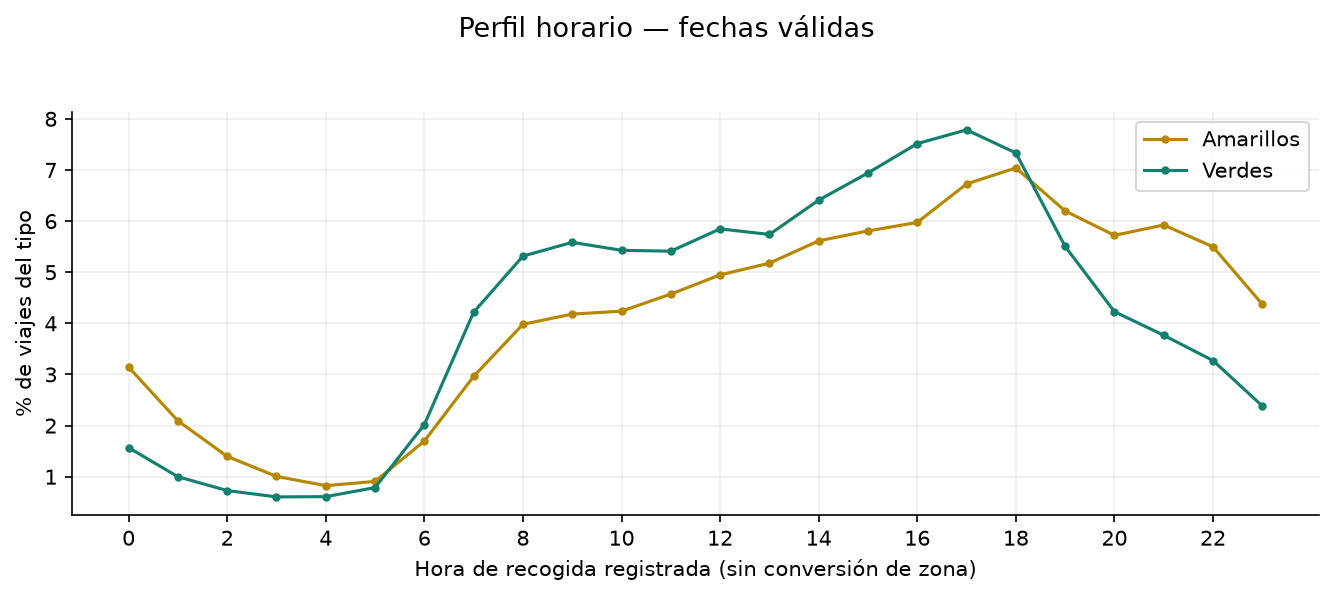

### 04_demanda_semanal

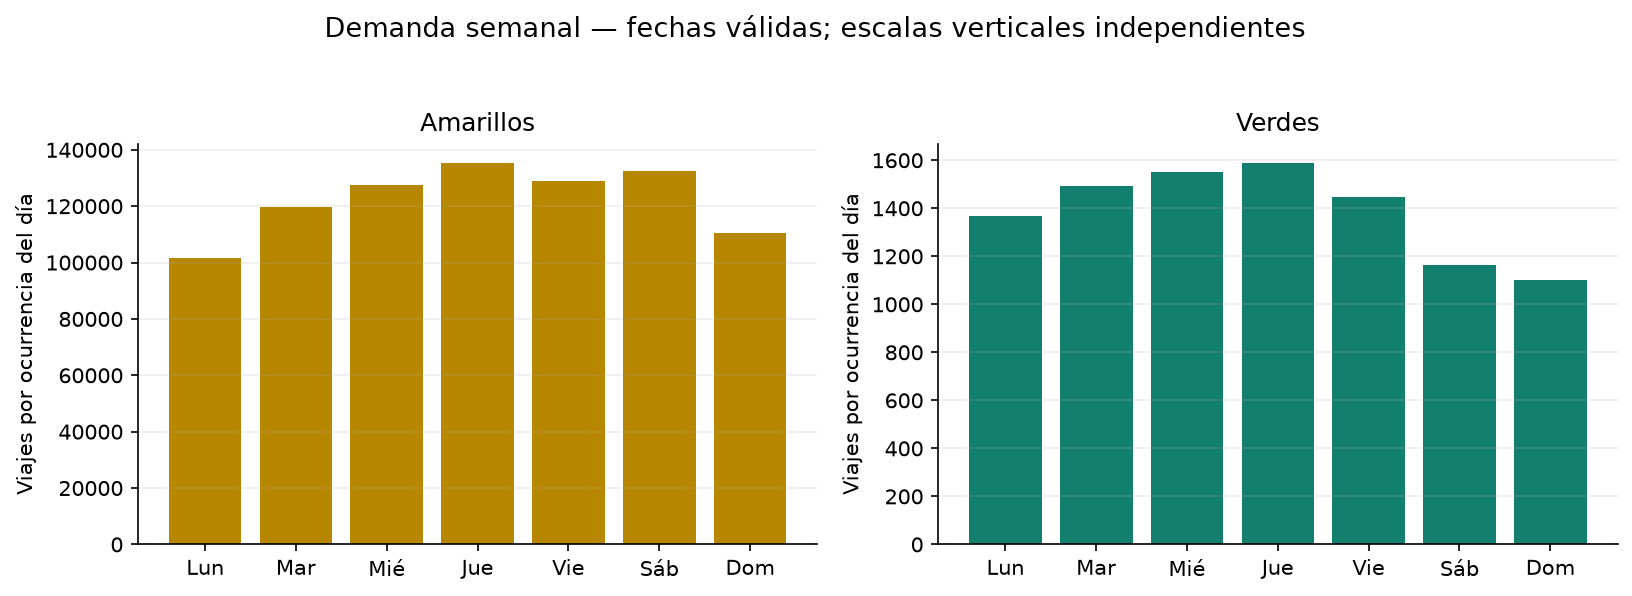

### 06_distribuciones

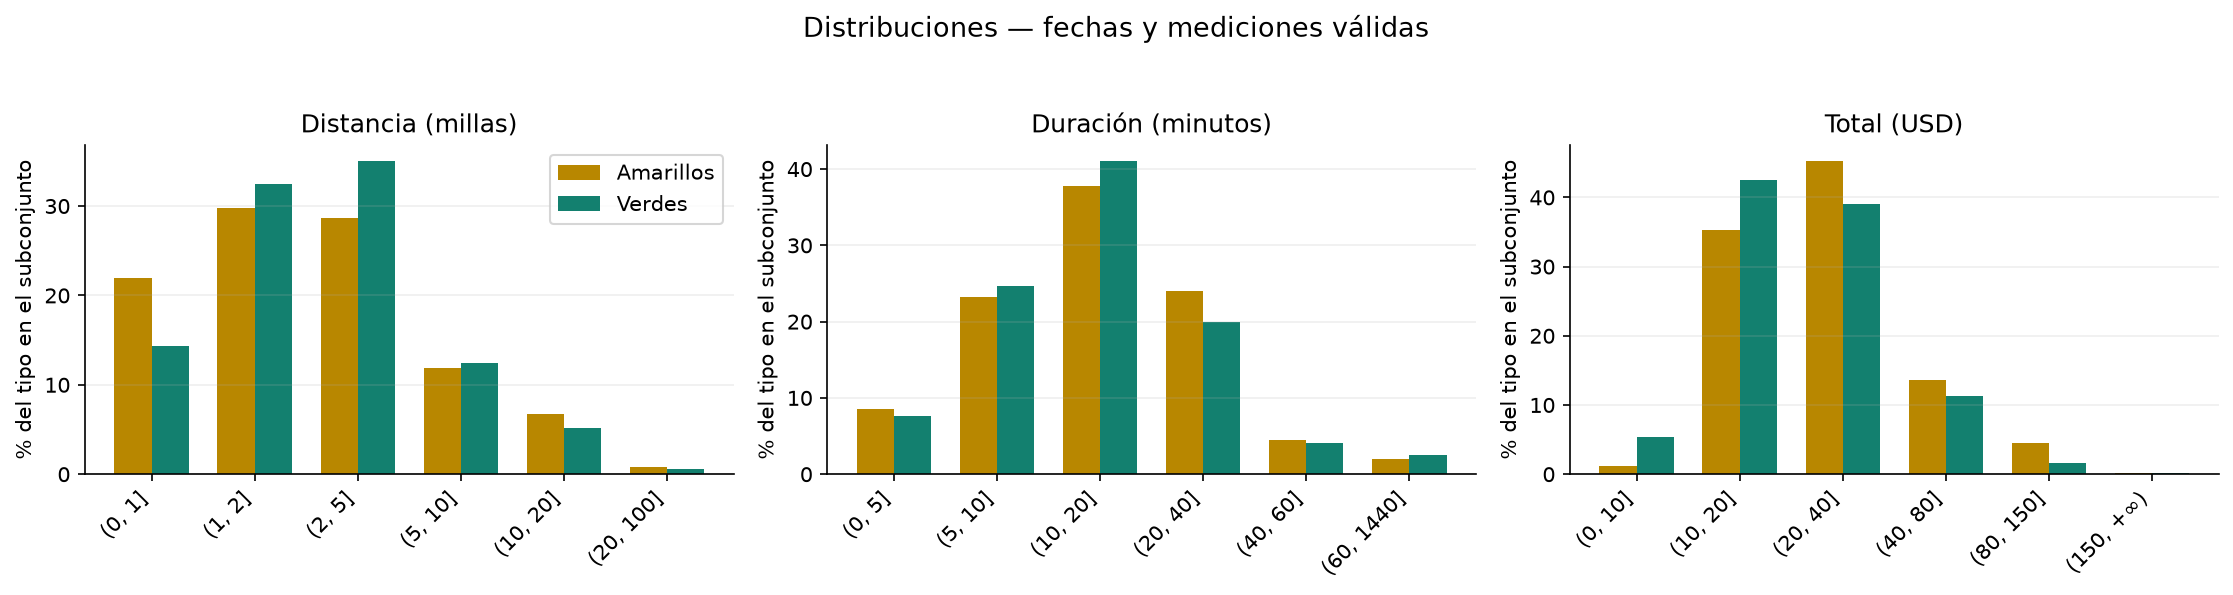

### 07_costo_distancia

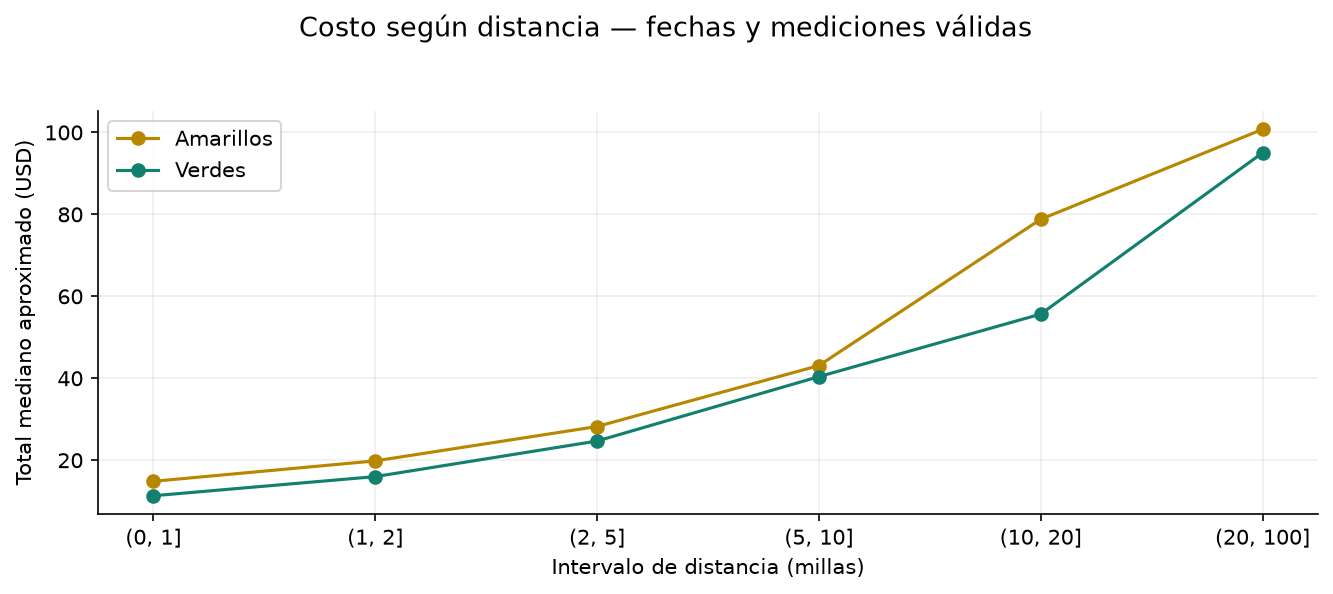

### 08_formas_pago

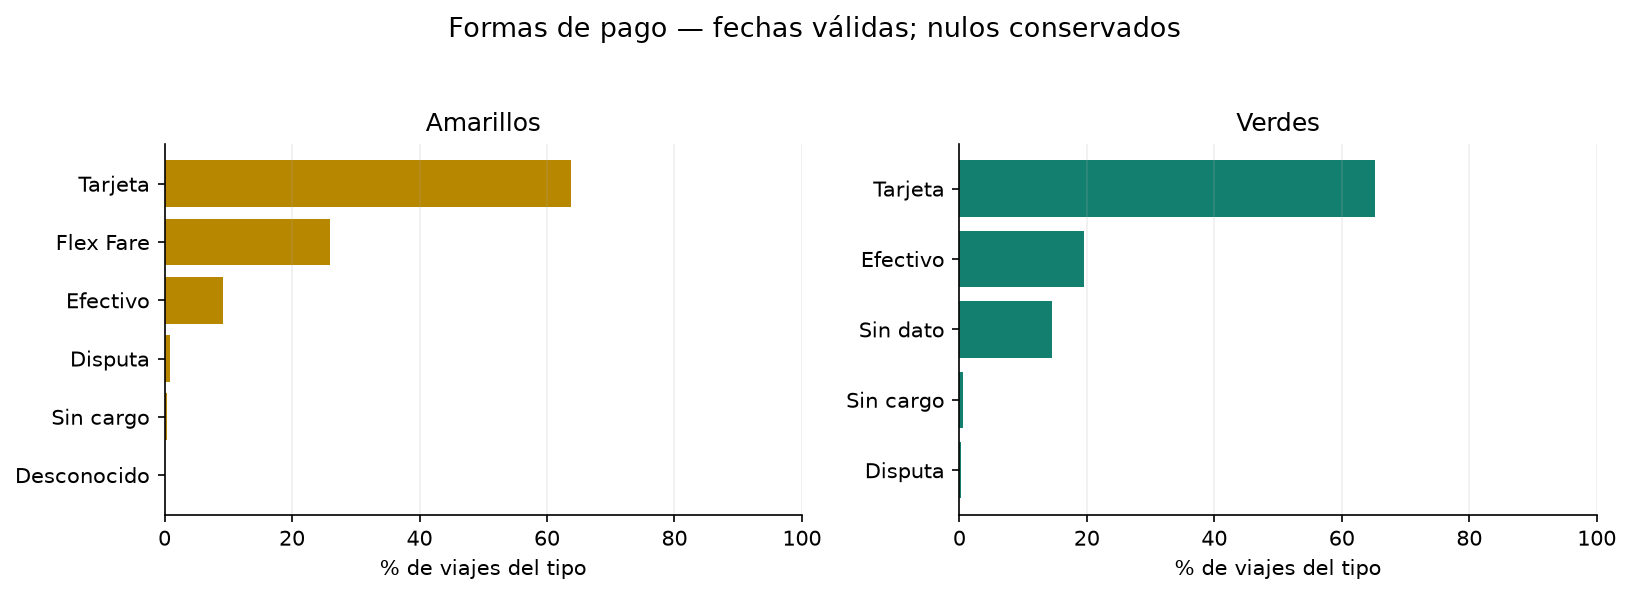

### 09_propinas_tarjeta

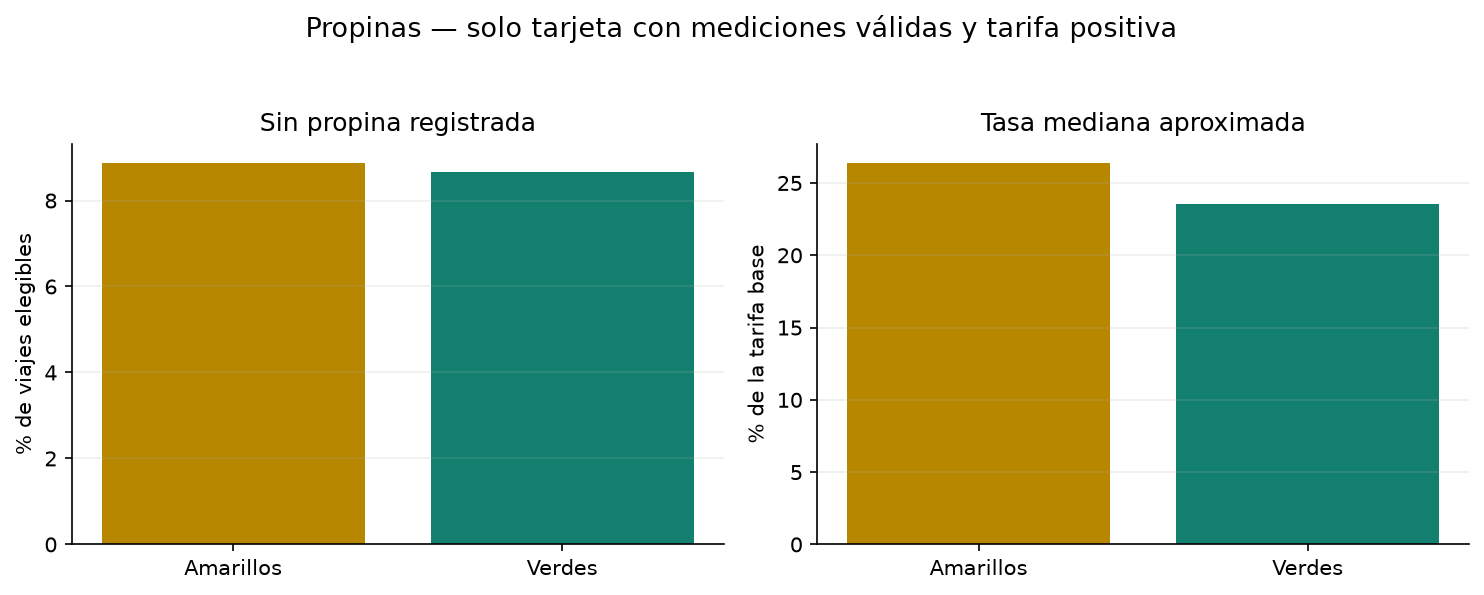

Documentación: docs/ejercicio_4_analisis.md


In [13]:
figures = plot_results(frames)
write_report(frames, figures)
for name, path in figures.items():
    display(Markdown("### " + name))
    display(Image(filename=str(path)))
print("Documentación: docs/ejercicio_4_analisis.md")

## Hallazgos respaldados por resultados

Se presentan valores calculados del conjunto actual, con su consulta de origen, población y límites de interpretación.

In [14]:
for i, text in enumerate(findings(frames), 1):
    display(Markdown(f"{i}. {text}"))
print("Tablas materializadas:", connection.execute(
    "SELECT count(*) FROM information_schema.tables WHERE table_type = 'BASE TABLE'"
).fetchone()[0])
connection.close()

1. **Demanda mensual, amarillos:** el máximo diario medio aparece en 2026-05, con 131,962.00 viajes/día; el mínimo en 2026-08, con 107,635.52. La diferencia máximo/mínimo es 22.60%. Se comparan promedios diarios, no meses de igual duración. Fuente: consulta 02; no demuestra estacionalidad recurrente con un solo tramo temporal.

2. **Patrón temporal, amarillos:** la hora con mayor proporción es 18:00–18:59 (7.04% del tipo); las horas 17–20 concentran 25.68%. Jueves presenta el mayor promedio semanal, 135,471.26 viajes por ocurrencia del día. Fuente: consultas 03–04; los calendarios están normalizados, pero no se controla por eventos o composición mensual.

3. **Demanda mensual, verdes:** el máximo diario medio aparece en 2026-04, con 1,474.50 viajes/día; el mínimo en 2026-01, con 1,298.39. La diferencia máximo/mínimo es 13.56%. Se comparan promedios diarios, no meses de igual duración. Fuente: consulta 02; no demuestra estacionalidad recurrente con un solo tramo temporal.

4. **Patrón temporal, verdes:** la hora con mayor proporción es 17:00–17:59 (7.78% del tipo); las horas 17–20 concentran 24.85%. Jueves presenta el mayor promedio semanal, 1,590.26 viajes por ocurrencia del día. Fuente: consultas 03–04; los calendarios están normalizados, pero no se controla por eventos o composición mensual.

5. **Diferencias en características:** las medianas aproximadas de distancia son 1.93 millas en amarillos y 2.14 en verdes; las duraciones medianas, 14.12 y 13.35 minutos; los totales medianos, USD 23.58 y USD 20.57. Fuente: consulta 05, solo mediciones válidas. No se igualan rutas, tarifas ni horarios, por lo que no se interpreta como diferencia causal de precio entre servicios.

...

10. **Importes negativos, amarillos:** 100,854 negativos están en pago tipo 4 (Disputa), equivalentes a 62.32% de los negativos del tipo. Dentro de esa categoría, 42.11% son negativos. Fuente: consulta 10. Es una asociación con la categoría reportada, no evidencia de que todo negativo sea un reembolso o error.

11. **Importes negativos, verdes:** 279 negativos están en pago tipo 4 (Disputa), equivalentes a 27.30% de los negativos del tipo. Dentro de esa categoría, 37.20% son negativos. Fuente: consulta 10. Es una asociación con la categoría reportada, no evidencia de que todo negativo sea un reembolso o error.

12. **Sensibilidad, amarillos:** la distancia media pasa de 5.55 a 3.52 millas, conservando 95.07% de los viajes con fechas válidas. Fuente: consulta 11. Los filtros cambian a la vez distancia, duración e importes; la diferencia no se atribuye exclusivamente a distancias extremas.

13. **Sensibilidad, verdes:** la distancia media pasa de 13.35 a 3.36 millas, conservando 96.04% de los viajes con fechas válidas. Fuente: consulta 11. Los filtros cambian a la vez distancia, duración e importes; la diferencia no se atribuye exclusivamente a distancias extremas.

Tablas materializadas: 0


## Límites y referencias

Los percentiles son aproximados y pueden variar ligeramente entre ejecuciones por procesamiento paralelo. No se concluye causalidad ni estacionalidad recurrente, no se igualan rutas u horarios, y no se extrapola a meses sin datos.

Las propinas en efectivo no están registradas según los diccionarios [amarillo](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) y [verde](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf). Por eso el análisis de propinas se limita a tarjeta. Las distancias se expresan en millas y los importes en USD; la tasa de propina se calcula sobre la tarifa base, no sobre el total.

Los resultados son descriptivos de las poblaciones declaradas. Las alertas requieren contexto y no justifican eliminar automáticamente importes negativos o pagos ausentes.